<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/04_natural_language_processing/11_gated_recurrent_unit_gru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gated Recurrent Unit (GRU)

Gated Recurrent Unit (GRU) is a type of recurrent neural network introduced to simplify the LSTM architecture while retaining its ability to learn long-term dependencies.

Unlike LSTM, which uses three gates and a separate memory cell, GRU uses only two gates: the Update Gate and the Reset Gate. These gates control how much past information should be retained and how much new information should be incorporated.

Because of its simpler architecture, GRUs generally train faster and require fewer parameters than LSTMs while achieving comparable performance on many Natural Language Processing tasks such as sentiment analysis, text classification, language modeling, and machine translation.

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
sentences = [

    "I love machine learning",

    "Deep learning is powerful",

    "Artificial intelligence is amazing",

    "Natural language processing is interesting"

]

In [3]:
tokenizer = tf.keras.preprocessing.text.Tokenizer()

tokenizer.fit_on_texts(sentences)

sequences = tokenizer.texts_to_sequences(sentences)

padded_sequences = tf.keras.preprocessing.sequence.pad_sequences(
    sequences,
    padding="post"
)

print(padded_sequences)

[[ 3  4  5  2  0]
 [ 6  2  1  7  0]
 [ 8  9  1 10  0]
 [11 12 13  1 14]]


In [4]:
labels = np.array([1, 1, 0, 0])

In [5]:
model = Sequential([

    Embedding(
        input_dim=100,
        output_dim=16,
        input_length=padded_sequences.shape[1]
    ),

    GRU(32),

    Dense(1, activation="sigmoid")

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [8]:
history = model.fit(
    padded_sequences,
    labels,
    epochs=10,
    verbose=1
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.2500 - loss: 0.6970
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7500 - loss: 0.6956
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7500 - loss: 0.6942
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5000 - loss: 0.6928
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5000 - loss: 0.6915
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 0.6901
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 1.0000 - loss: 0.6886
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 1.0000 - loss: 0.6872
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 1.0000 - loss: 0.6856
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.6840


In [9]:
predictions = model.predict(padded_sequences)

print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
[[0.5081014 ]
 [0.5052314 ]
 [0.49494126]
 [0.49640983]]


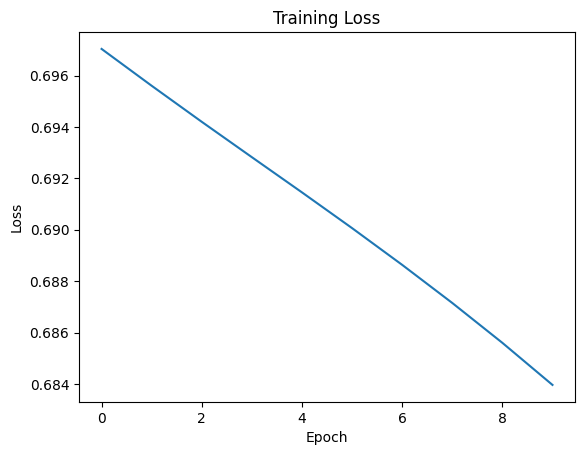

In [10]:
plt.plot(history.history["loss"])

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [11]:
comparison = pd.DataFrame({

    "RNN":[
        "Hidden state only",
        "Short-term memory",
        "Simple architecture",
        "Few parameters"
    ],

    "LSTM":[
        "Memory cell + 3 gates",
        "Long-term memory",
        "Complex architecture",
        "More parameters"
    ],

    "GRU":[
        "2 gates",
        "Long-term memory",
        "Simpler than LSTM",
        "Fewer parameters"
    ]

})

comparison

,RNN,LSTM,GRU
0,Hidden state only,Memory cell + 3 gates,2 gates
1,Short-term memory,Long-term memory,Long-term memory
2,Simple architecture,Complex architecture,Simpler than LSTM
3,Few parameters,More parameters,Fewer parameters


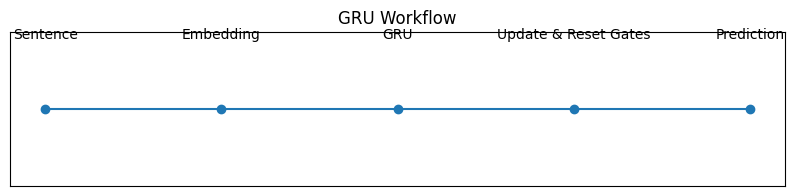

In [12]:
steps = [

    "Sentence",

    "Embedding",

    "GRU",

    "Update & Reset Gates",

    "Prediction"

]

plt.figure(figsize=(10,2))

plt.plot(
    range(len(steps)),
    [1]*len(steps),
    marker="o"
)

for i, step in enumerate(steps):
    plt.text(i, 1.05, step, ha="center")

plt.xticks([])
plt.yticks([])

plt.title("GRU Workflow")

plt.show()